# KPI Reporting Layer — CA Housing Price Analysis

**Author:** Sahithi Locharala  
**Database:** `locharv_cap1` on `mysql.clarksonmsda.org`  
**LLM table:** `ca_median_prices` (models: llama2, llama3.1, llama3.1:latest, codellama:7b, gemma3)  
**Actual data:** `ca_actual_prices` (loaded from `MedianPricesofExistingDetachedHomesHistoricalData.csv`)  
**Focus area:** Los Angeles (LA Metro)

---
This notebook implements a SQL-backed KPI framework on top of the existing pipeline.
It covers:
1. DB connection & schema validation
2. ETL — load actual CAR prices into `ca_actual_prices`
3. KPI 1 — Monthly accuracy (percent_error, MAPE) — extends your notebook's `comparison` logic
4. KPI 2 — Model leaderboard
5. KPI 3 — Quarterly trend & QoQ growth
6. KPI 4 — Variance suppression
7. KPI 5 — Run quality scorecard
8. KPI 6 — Seasonal bias
9. KPI 7 — Annual summary
10. Ad-hoc: block-level bias analysis (from your notebook) promoted to a reusable function
11. Data quality audit log


## 0. Dependencies & DB Connection

In [5]:
#!pip install sqlalchemy pymysql python-dotenv

In [6]:
from dotenv import load_dotenv
import os
load_dotenv()

DB_HOST = os.environ['DB_HOST']
DB_USER = os.environ['DB_USER']
DB_PASS = os.environ['DB_PASS']
DB_NAME = os.environ['DB_NAME']

In [11]:
import pandas as pd
import numpy as np
import pymysql
import sqlalchemy as sa
from sqlalchemy import text
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Connection — same host/db as your existing notebook ──────────────────────
DB_HOST = DB_HOST
DB_USER = DB_USER
DB_PASS = DB_PASS
DB_NAME = DB_NAME

engine = sa.create_engine(
    'mysql+pymysql://',
    creator=lambda: pymysql.connect(
        host=DB_HOST,
        user=DB_USER,
        password=DB_PASS,
        database=DB_NAME)
)

def run_query(sql: str) -> pd.DataFrame:
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print('Connected to', DB_NAME)

Connected to locharv_cap1


## 1. Schema Validation

In [12]:
schema_df = run_query("""
    SELECT table_name, table_type
    FROM   information_schema.tables
    WHERE  table_schema = 'locharv_cap1'
    ORDER  BY table_type, table_name
""")
print(f'{len(schema_df)} objects in locharv_cap1')
schema_df

12 objects in locharv_cap1


,TABLE_NAME,TABLE_TYPE
0,House_prices,BASE TABLE
1,ca_actual_prices,BASE TABLE
2,ca_median_prices,BASE TABLE
3,ca_quality_audit,BASE TABLE
4,movie_reviews,BASE TABLE
5,vw_kpi_annual_summary,VIEW
6,vw_kpi_model_leaderboard,VIEW
7,vw_kpi_monthly_accuracy,VIEW
8,vw_kpi_quarterly_trend,VIEW
9,vw_kpi_run_quality,VIEW


## 2. ETL — Load Actual CAR Prices into `ca_actual_prices`

Reads the cleaned `HomeMedianPrices.csv` produced by your preprocessing notebook,
maps `LA Metro` → `Los Angeles`, and upserts into `ca_actual_prices`.

In [13]:
# ── Read the cleaned CSV (output of your CA_housing_price.ipynb) ──────────────
actual_df = pd.read_csv('HomeMedianPrices.csv')

# The CSV has Mon-Yr column (YYYY-MM after your cleaning) + region price columns
print('Columns:', actual_df.columns.tolist())
print('Shape  :', actual_df.shape)
actual_df.head(3)

Columns: ['Mon-Yr', 'CA', 'Alameda', 'Amador', 'Butte', 'Calaveras', 'Contra-Costa', 'Del Norte', 'El Dorado', 'Fresno', 'Glenn', 'Humboldt', 'Imperial', 'Kern', 'Kings', 'Lake', 'Lassen', 'Los Angeles', 'Madera', 'Marin', 'Mariposa', 'Mendocino', 'Merced', 'Mono', 'Monterey', 'Napa', 'Nevada', 'Orange', 'Placer', 'Plumas', 'Riverside', 'Sacramento', 'San Benito', 'San Bernardino', 'San Diego', 'San Francisco', 'San Joaquin', 'San Luis Obispo', 'San Mateo', 'Santa Barbara', 'Santa Clara', 'Santa Cruz', 'Shasta', 'Siskiyou', 'Solano', 'Sonoma', 'Stanislaus', 'Sutter', 'Tehama', 'Trinity', 'Tulare', 'Tuolumne', 'Ventura', 'Yolo', 'Yuba', 'Condo', 'LA Metro', 'Central Coast', 'Central Valley', 'Far North', 'Inland Empire', 'S.F. Bay Area', 'SoCal', 'Date']
Shape  : (428, 64)


,Mon-Yr,CA,Alameda,Amador,Butte,Calaveras,Contra-Costa,Del Norte,El Dorado,Fresno,...,Yuba,Condo,LA Metro,Central Coast,Central Valley,Far North,Inland Empire,S.F. Bay Area,SoCal,Date
0,Jan-1990,194952.0,226149.0,NaN,102143.0,NaN,NaN,NaN,NaN,82083.0,...,NaN,141519.0,203390.0,NaN,NaN,NaN,NaN,227366.0,NaN,1990-01-01
1,Feb-1990,196273.0,219306.0,NaN,83333.0,NaN,NaN,NaN,NaN,87187.0,...,NaN,144965.0,211024.0,NaN,NaN,NaN,NaN,234739.0,NaN,1990-02-01
2,Mar-1990,194856.0,225162.0,NaN,100000.0,NaN,NaN,NaN,NaN,83889.0,...,NaN,141132.0,209286.0,NaN,NaN,NaN,NaN,235337.0,NaN,1990-03-01


In [14]:
# ── Build long-form table: one row per (month, area, price) ──────────────────
# Map CSV column names → area labels used in ca_median_prices
AREA_MAP = {
    'LA Metro':          'Los Angeles',
    'CA':                'CA',           # statewide
    'SF Bay Area':       'San Francisco',
    'San Diego':         'San Diego',
    # add more if needed
}

rows = []
for csv_col, area_label in AREA_MAP.items():
    if csv_col not in actual_df.columns:
        print(f'  Skipping {csv_col} — not in CSV')
        continue
    sub = actual_df[['Mon-Yr', csv_col]].copy()
    sub.columns = ['month', 'actual_price_usd']
    sub['area'] = area_label
    rows.append(sub)

actual_long = pd.concat(rows, ignore_index=True)

# ── Validation ────────────────────────────────────────────────────────────────
pre = len(actual_long)
actual_long['actual_price_usd'] = pd.to_numeric(actual_long['actual_price_usd'], errors='coerce')
actual_long = actual_long.dropna(subset=['month','actual_price_usd'])
actual_long = actual_long[
    actual_long['actual_price_usd'].between(100_000, 5_000_000)
]
actual_long['actual_price_usd'] = actual_long['actual_price_usd'].astype(int)
print(f'Rows before validation: {pre:,} | after: {len(actual_long):,}')
actual_long.head()

  Skipping SF Bay Area — not in CSV
Rows before validation: 1,284 | after: 1,284


,month,actual_price_usd,area
0,Jan-1990,203390,Los Angeles
1,Feb-1990,211024,Los Angeles
2,Mar-1990,209286,Los Angeles
3,Apr-1990,210302,Los Angeles
4,May-1990,210148,Los Angeles


In [15]:
# ── Write to ca_actual_prices (replace on re-run to keep idempotent) ──────────
actual_long.to_sql(
    'ca_actual_prices', con=engine,
    if_exists='replace', index=False
)
print(f'Loaded {len(actual_long):,} rows into ca_actual_prices')

Loaded 1,284 rows into ca_actual_prices


In [21]:
print("=== ca_actual_prices areas ===")
print(run_query("SELECT DISTINCT area FROM ca_actual_prices"))

print("=== ca_median_prices areas ===")
print(run_query("SELECT DISTINCT Area FROM ca_median_prices"))

=== ca_actual_prices areas ===
          area
0  Los Angeles
1           CA
2    San Diego
=== ca_median_prices areas ===
          Area
0  Los Angeles


In [22]:
print("=== ca_actual_prices months (sample) ===")
print(run_query("SELECT month FROM ca_actual_prices LIMIT 5"))

print("=== ca_median_prices months (sample) ===")
print(run_query("SELECT month FROM ca_median_prices LIMIT 5"))

=== ca_actual_prices months (sample) ===
      month
0  Jan-1990
1  Feb-1990
2  Mar-1990
3  Apr-1990
4  May-1990
=== ca_median_prices months (sample) ===
     month
0  2023-01
1  2023-01
2  2023-01
3  2023-01
4  2023-01


In [23]:
import pandas as pd
from sqlalchemy import text

# Read CSV
actual_raw = pd.read_csv('HomeMedianPrices.csv')

# Convert Mon-Yr column to YYYY-MM format
actual_raw['month'] = pd.to_datetime(actual_raw['Mon-Yr'], format='mixed').dt.strftime('%Y-%m')

# Build long-form table
AREA_MAP = {
    'Los Angeles': 'Los Angeles',
    'CA':          'CA',
    'San Diego':   'San Diego',
}

rows = []
for csv_col, area_label in AREA_MAP.items():
    if csv_col not in actual_raw.columns:
        print(f'Skipping {csv_col} — not found in CSV')
        continue
    sub = actual_raw[['month', csv_col]].copy()
    sub.columns = ['month', 'actual_price_usd']
    sub['area'] = area_label
    rows.append(sub)

actual_long = pd.concat(rows, ignore_index=True)

# Validate
actual_long['actual_price_usd'] = pd.to_numeric(actual_long['actual_price_usd'], errors='coerce')
actual_long = actual_long.dropna(subset=['month', 'actual_price_usd'])
actual_long = actual_long[actual_long['actual_price_usd'].between(100_000, 5_000_000)]

# Reload table with correct month format
actual_long.to_sql('ca_actual_prices', con=engine, if_exists='replace', index=False)
print(f'Loaded {len(actual_long):,} rows')
print(actual_long['month'].head())

Loaded 1,284 rows
0    1990-01
1    1990-02
2    1990-03
3    1990-04
4    1990-05
Name: month, dtype: object


In [24]:
run_query("""
    SELECT a.area, a.month, a.actual_price_usd, s.version, s.median_price_usd
    FROM ca_actual_prices a
    JOIN ca_median_prices s ON s.Area = a.area AND s.month = a.month
    LIMIT 5
""")

,area,month,actual_price_usd,version,median_price_usd
0,Los Angeles,2023-01,778540.0,llama3.1:8b-instruct-q4_0,134567
1,Los Angeles,2023-01,778540.0,llama3.1:8b-instruct-q4_0,124995
2,Los Angeles,2023-01,778540.0,llama3.1:8b-instruct-q4_0,1456320
3,Los Angeles,2023-01,778540.0,llama3.1:latest,950000
4,Los Angeles,2023-01,778540.0,llama3.1:8b-instruct-q8_0,542123


## 3. KPI 1 — Monthly Accuracy (extends your `comparison` DataFrame logic)

In [25]:
# Mirrors your notebook: difference = actual - llm, percent_error = difference/actual * 100
kpi1 = run_query("""
    SELECT area, month, version,
           actual_price_usd,
           avg_llm_price,
           price_difference,
           percent_error,
           abs_pct_error
    FROM vw_kpi_monthly_accuracy
    WHERE area = 'Los Angeles'
    ORDER BY version, month
""")

print(f'Records: {len(kpi1):,}')
print('\nMAPE per model:')
kpi1.groupby('version')['abs_pct_error'].agg(
    mean_mape='mean', median_mape='median', max_mape='max'
).round(2)

Records: 108

MAPE per model:


,mean_mape,median_mape,max_mape
version,,,
llama3.1:8b,7.58,8.10,15.66
llama3.1:8b-instruct-q4_0,7.75,7.88,17.96
llama3.1:8b-instruct-q8_0,12.03,12.54,20.32
llama3.1:latest,23.28,21.08,35.03


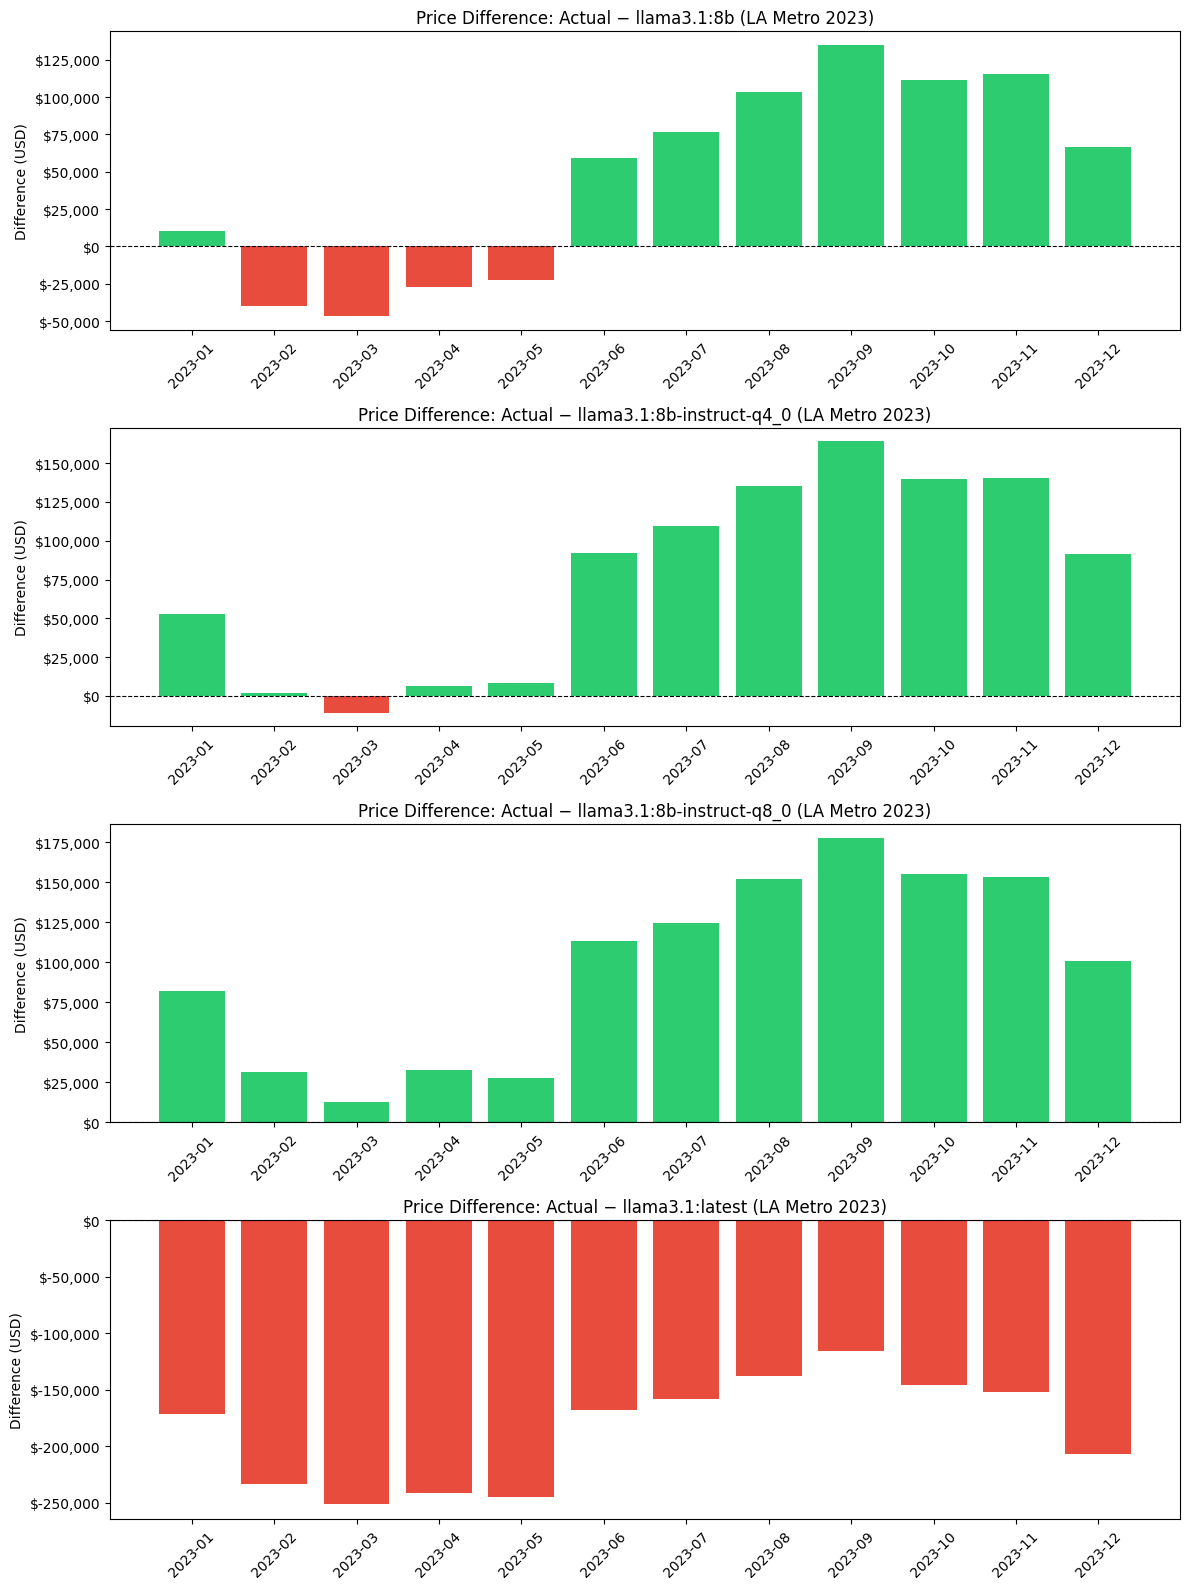

Saved: kpi1_monthly_difference_2023.png


In [26]:
# ── Replicate your price-difference bar chart — now from SQL KPI view ─────────
kpi1_2023 = kpi1[kpi1['month'].str.startswith('2023')]

models = kpi1_2023['version'].unique()
fig, axes = plt.subplots(len(models), 1,
                         figsize=(12, 4 * len(models)), sharex=False)

for ax, version in zip(axes if len(models) > 1 else [axes], models):
    sub = kpi1_2023[kpi1_2023['version'] == version].sort_values('month')
    ax.bar(sub['month'], sub['price_difference'],
           color=['#e74c3c' if v < 0 else '#2ecc71' for v in sub['price_difference']])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Price Difference: Actual − {version} (LA Metro 2023)')
    ax.set_ylabel('Difference (USD)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('kpi1_monthly_difference_2023.png', dpi=150)
plt.show()
print('Saved: kpi1_monthly_difference_2023.png')

## 4. KPI 2 — Model Leaderboard

In [29]:
leaderboard = run_query("""
    SELECT accuracy_rank, version, total_runs, total_predictions,
           overall_mape_pct, avg_bias_dollars, bias_direction
    FROM vw_kpi_model_leaderboard
    ORDER BY accuracy_rank
""")
print('Model Accuracy Leaderboard (lower MAPE = better):')
leaderboard

Model Accuracy Leaderboard (lower MAPE = better):


,accuracy_rank,version,total_runs,total_predictions,overall_mape_pct,avg_bias_dollars,bias_direction
0,1,llama3.1:8b-instruct-q4_0,15,420,21.05,69266.0,LLM_UNDERSHOOTS
1,2,llama3.1:latest,1,12,23.28,-185646.0,LLM_OVERSHOOTS
2,3,llama3.1:8b,14,408,29.17,57789.0,LLM_UNDERSHOOTS
3,4,llama3.1:8b-instruct-q8_0,12,324,32.61,104975.0,LLM_UNDERSHOOTS


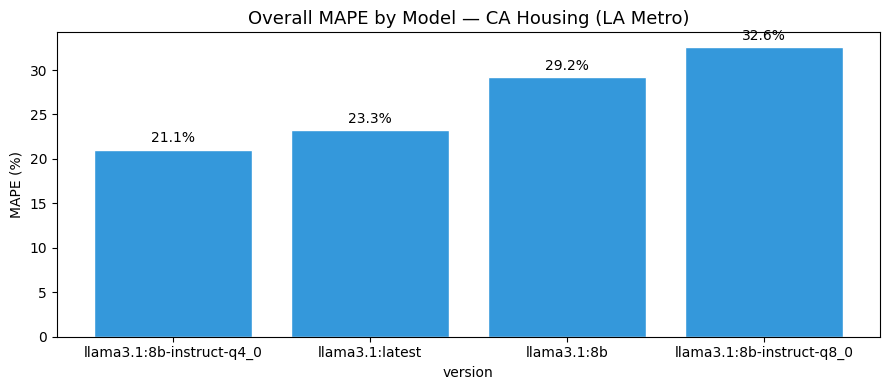

In [31]:
# Bar chart of MAPE by model
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(leaderboard['version'], leaderboard['overall_mape_pct'],
              color='#3498db', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('Overall MAPE by Model — CA Housing (LA Metro)', fontsize=13)
ax.set_ylabel('MAPE (%)')
ax.set_xlabel('version')
plt.tight_layout()
plt.savefig('kpi2_model_leaderboard.png', dpi=150)
plt.show()

## 5. KPI 3 — Quarterly Trend & QoQ Growth

In [32]:
kpi3 = run_query("""
    SELECT version, area, yr, qtr,
           avg_actual, avg_llm,
           quarterly_price_diff,
           actual_qoq_growth_pct,
           llm_qoq_growth_pct
    FROM vw_kpi_quarterly_trend
    WHERE area = 'Los Angeles'
    ORDER BY version, yr, qtr
""")

# Pivot: actual avg price by quarter (one column per version + actual)
pivot_q = kpi3.pivot_table(
    index=['yr','qtr'], columns='version',
    values='avg_llm', aggfunc='mean'
).round(0)

# Add actual (same for all versions per quarter)
actual_q = kpi3.drop_duplicates(['yr','qtr']).set_index(['yr','qtr'])['avg_actual']
pivot_q.insert(0, 'Actual', actual_q)

print('Quarterly avg price — Actual vs each LLM version:')
pivot_q.tail(8)

Quarterly avg price — Actual vs each LLM version:


version     Actual  llama3.1:8b  llama3.1:8b-instruct-q4_0  \
yr   qtr                                                     
2023 4    881660.0     783807.0                   757577.0   
2024 1    818400.0     805616.0                   792919.0   
     2    842253.0     808720.0                   802185.0   
     3    929757.0     809932.0                   809564.0   
     4    935203.0     809686.0                   817491.0   
2025 1    855950.0     814181.0                   825287.0   
     2    863133.0     819638.0                   832705.0   
     3    921040.0     819409.0                   837947.0   

version   llama3.1:8b-instruct-q8_0  llama3.1:latest  
yr   qtr                                              
2023 4                     745352.0        1050000.0  
2024 1                     743337.0              NaN  
     2                     748450.0              NaN  
     3                     761989.0              NaN  
     4                     766768.0              NaN  
2025 1                     778547.0              NaN  
     2                     785243.0              NaN  
     3                     796930.0              NaN

## 6. KPI 4 — Variance Suppression

In [34]:
kpi4 = run_query("""
    SELECT version, area,
           actual_stddev, llm_stddev,
           actual_cv_pct, llm_cv_pct,
           variance_suppression_ratio, smoothing_label
    FROM vw_kpi_variance_suppression
    WHERE area = 'Los Angeles'
    ORDER BY variance_suppression_ratio DESC
""")

print('Variance Suppression by Version:')
print(kpi4['smoothing_label'].value_counts().to_string(), '\n')
kpi4

Variance Suppression by Version:
smoothing_label
LOW_SMOOTHING     3
HIGH_SMOOTHING    1 



,version,area,actual_stddev,llm_stddev,actual_cv_pct,llm_cv_pct,variance_suppression_ratio,smoothing_label
0,llama3.1:latest,Los Angeles,70430.0,34521.0,8.60,3.43,0.5099,HIGH_SMOOTHING
1,llama3.1:8b-instruct-q4_0,Los Angeles,66225.0,308177.0,7.76,39.31,-3.6535,LOW_SMOOTHING
2,llama3.1:8b,Los Angeles,65833.0,363080.0,7.71,45.58,-4.5152,LOW_SMOOTHING
3,llama3.1:8b-instruct-q8_0,Los Angeles,66580.0,396726.0,7.81,53.08,-4.9586,LOW_SMOOTHING


## 7. KPI 5 — Run Quality Scorecard

In [35]:
scorecard = run_query("""
    SELECT run_id, version, area,
           total_records, null_prices, out_of_range,
           valid_records, validity_rate_pct, quality_gate
    FROM vw_kpi_run_quality
    ORDER BY run_id
""")

print('Quality Gate Summary:')
print(scorecard['quality_gate'].value_counts().to_string(), '\n')

scorecard.style.applymap(
    lambda v: 'background-color: #c8f7c5' if v == 'PASS'
              else ('background-color: #fdebd0' if v == 'WARN'
              else 'background-color: #f9caca'),
    subset=['quality_gate']
)

Quality Gate Summary:
quality_gate
PASS    36
FAIL     5
WARN     1 



,run_id,version,area,total_records,null_prices,out_of_range,valid_records,validity_rate_pct,quality_gate
0,20251106180142,llama3.1:8b-instruct-q4_0,Los Angeles,12,0.000000,0.000000,12.000000,100.000000,PASS
1,20251106180429,llama3.1:8b-instruct-q4_0,Los Angeles,12,0.000000,0.000000,12.000000,100.000000,PASS
2,20251106182250,llama3.1:8b-instruct-q4_0,Los Angeles,12,0.000000,0.000000,12.000000,100.000000,PASS
3,20251106184208,llama3.1:latest,Los Angeles,12,0.000000,0.000000,12.000000,100.000000,PASS
4,20251119102438,llama3.1:8b-instruct-q8_0,Los Angeles,12,0.000000,0.000000,12.000000,100.000000,PASS
5,20251119103113,llama3.1:8b-instruct-q8_0,Los Angeles,12,0.000000,0.000000,12.000000,100.000000,PASS
6,20251119104915,llama3.1:8b-instruct-q8_0,Los Angeles,12,0.000000,0.000000,12.000000,100.000000,PASS
7,20251119111517,llama3.1:8b,Los Angeles,12,0.000000,0.000000,12.000000,100.000000,PASS
8,20251119112737,llama3.1:8b,Los Angeles,12,0.000000,0.000000,12.000000,100.000000,PASS
9,20251120154539,llama3.1:8b,Los Angeles,35,0.000000,0.000000,35.000000,100.000000,PASS


## 8. KPI 6 — Seasonal Bias

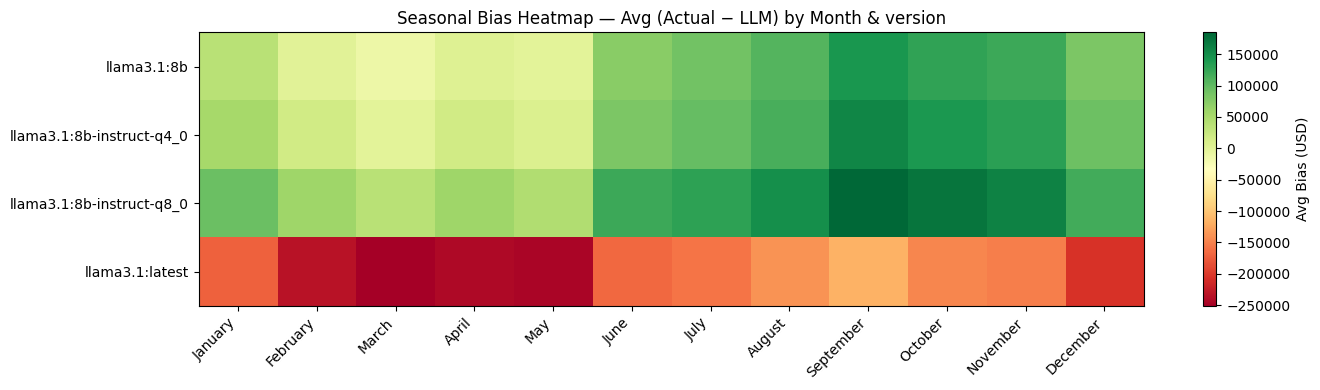

In [36]:
kpi6 = run_query("""
    SELECT version, month_num, month_name,
           avg_bias_dollars, avg_abs_pct_error, observations
    FROM vw_kpi_seasonal_bias
    WHERE area = 'Los Angeles'
    ORDER BY version, month_num
""")

# Heatmap: bias by version x calendar month
heat = kpi6.pivot_table(
    index='version', columns='month_name',
    values='avg_bias_dollars', aggfunc='mean'
)
# Reorder months Jan→Dec
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
heat = heat.reindex(columns=[m for m in month_order if m in heat.columns])

fig, ax = plt.subplots(figsize=(14, 4))
import matplotlib.colors as mcolors
cmap = plt.cm.RdYlGn
im = ax.imshow(heat.values, aspect='auto', cmap=cmap)
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=45, ha='right')
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title('Seasonal Bias Heatmap — Avg (Actual − LLM) by Month & version', fontsize=12)
plt.colorbar(im, ax=ax, label='Avg Bias (USD)')
plt.tight_layout()
plt.savefig('kpi6_seasonal_bias_heatmap.png', dpi=150)
plt.show()

## 9. KPI 7 — Annual Summary

In [37]:
kpi7 = run_query("""
    SELECT version, area, year,
           avg_actual_price, avg_llm_price,
           avg_bias_dollars, annual_mape_pct,
           months_covered
    FROM vw_kpi_annual_summary
    WHERE area = 'Los Angeles'
    ORDER BY version, year
""")

print('Annual KPI Summary (LA Metro):')
kpi7

Annual KPI Summary (LA Metro):


,version,area,year,avg_actual_price,avg_llm_price,avg_bias_dollars,annual_mape_pct,months_covered
0,llama3.1:8b,Los Angeles,2023,819354.0,774298.0,45056.0,29.50,12
1,llama3.1:8b,Los Angeles,2024,881403.0,808489.0,72915.0,28.70,12
2,llama3.1:8b,Los Angeles,2025,874916.0,817535.0,57382.0,29.32,8
3,llama3.1:8b-instruct-q4_0,Los Angeles,2023,819354.0,741722.0,77632.0,29.47,12
4,llama3.1:8b-instruct-q4_0,Los Angeles,2024,881403.0,805540.0,75864.0,14.44,12
5,llama3.1:8b-instruct-q4_0,Los Angeles,2025,874916.0,831234.0,43682.0,15.17,8
6,llama3.1:8b-instruct-q8_0,Los Angeles,2023,819354.0,722492.0,96862.0,31.71,12
7,llama3.1:8b-instruct-q8_0,Los Angeles,2024,881403.0,755136.0,126267.0,32.24,12
8,llama3.1:8b-instruct-q8_0,Los Angeles,2025,874916.0,785654.0,89263.0,34.96,8
9,llama3.1:latest,Los Angeles,2023,819354.0,1005000.0,-185646.0,23.28,12


## 10. Ad-Hoc: Block-Level Bias Analysis

Promoted from your notebook's block-averaging logic into a reusable function.
Useful for spotting era-level drift without needing to know exact date boundaries.

No data for version=llama2, area=Los Angeles
No data for version=llama3.1, area=Los Angeles


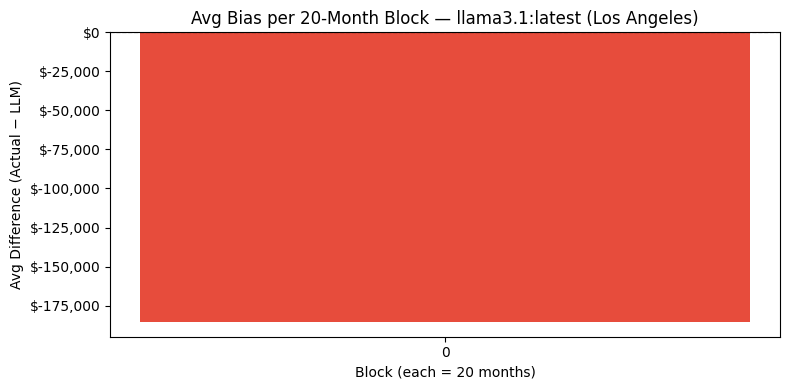

Saved: kpi_block_bias_llama3.1_latest_20mo.png
No data for version=codellama:7b, area=Los Angeles
No data for version=gemma3, area=Los Angeles


In [39]:
def plot_block_bias(model_name: str, area: str = 'Los Angeles',
                    block_size: int = 20):
    """
    Replicates your notebook's block-averaging chart:
    groups observations into blocks of `block_size` and plots avg bias per block.
    """
    df = run_query(f"""
        SELECT month, price_difference
        FROM   vw_kpi_monthly_accuracy
        WHERE  area  = '{area}'
          AND  version = '{model_name}'
        ORDER  BY month
    """)

    if df.empty:
        print(f'No data for version={model_name}, area={area}')
        return

    df['block'] = np.arange(len(df)) // block_size
    block_avg = (
        df.groupby('block')['price_difference']
          .mean()
          .reset_index()
          .rename(columns={'price_difference': 'avg_bias'})
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(block_avg['block'], block_avg['avg_bias'],
           color=['#e74c3c' if v < 0 else '#2ecc71' for v in block_avg['avg_bias']])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Avg Bias per {block_size}-Month Block — {model_name} ({area})')
    ax.set_xlabel(f'Block (each = {block_size} months)')
    ax.set_ylabel('Avg Difference (Actual − LLM)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_xticks(block_avg['block'])
    plt.tight_layout()
    fname = f'kpi_block_bias_{model_name.replace(":","_")}_{block_size}mo.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f'Saved: {fname}')
    return block_avg


# Run for each model
MODELS = ['llama2', 'llama3.1', 'llama3.1:latest', 'codellama:7b', 'gemma3']
for m in MODELS:
    plot_block_bias(m, block_size=20)

## 11. Data Quality Audit Log

In [46]:
with engine.begin() as conn:
    conn.execute(text("ALTER TABLE ca_quality_audit CHANGE model version VARCHAR(100)"))
print("Done — column renamed to version")

Done — column renamed to version


In [48]:
with engine.begin() as conn:
    conn.execute(text("ALTER TABLE ca_quality_audit MODIFY COLUMN run_id BIGINT NOT NULL"))
print("Done — run_id column changed to BIGINT")

Done — run_id column changed to BIGINT


In [49]:
def log_quality_check(run_id: int, version: str, area: str,
                       check_name: str, records_checked: int,
                       records_failed: int, severity: str = 'info'):
    """Write a quality-check result to ca_quality_audit."""
    rate = records_failed / records_checked if records_checked else 0
    with engine.begin() as conn:
        conn.execute(text("""
            INSERT INTO ca_quality_audit
                (run_id, version, area, check_name,
                 records_checked, records_failed, failure_rate, severity)
            VALUES
                (:run_id, :version, :area, :check_name,
                 :checked, :failed, :rate, :severity)
        """), {
            'run_id': run_id, 'version': version, 'area': area,
            'check_name': check_name,
            'checked': records_checked, 'failed': records_failed,
            'rate': round(rate, 4), 'severity': severity
        })
    flag = 'WARNING' if severity != 'info' else 'OK'
    print(f'[{flag}] {check_name} | failure rate: {rate:.2%}')


# ── Example: run after each generation batch ──────────────────────────────────
# Auto-compute null and out-of-range counts from the live table, then log:
def audit_run(run_id: int):
    summary = run_query(f"""
        SELECT version, area, null_prices, out_of_range, total_records
        FROM vw_kpi_run_quality
        WHERE run_id = {run_id}
    """)
    for _, row in summary.iterrows():
        log_quality_check(
            run_id, row['version'], row['area'],
            'null_price_check', row['total_records'], row['null_prices'],
            severity='warning' if row['null_prices'] > 0 else 'info'
        )
        log_quality_check(
            run_id, row['version'], row['area'],
            'out_of_range_check', row['total_records'], row['out_of_range'],
            severity='critical' if row['out_of_range'] > 0 else 'info'
        )

audit_run(20251106180142)  # uncomment and pass your actual run_id

[OK] null_price_check | failure rate: 0.00%
[OK] out_of_range_check | failure rate: 0.00%


In [51]:
# View audit history
audit_log = run_query("""
    SELECT log_id, run_id, version, area, check_name,
           records_checked, records_failed,
           ROUND(failure_rate * 100, 2) AS failure_rate_pct,
           severity, logged_at
    FROM ca_quality_audit
    ORDER BY logged_at DESC
    LIMIT 50
""")
audit_log

,log_id,run_id,version,area,check_name,records_checked,records_failed,failure_rate_pct,severity,logged_at
0,2,20251106180142,llama3.1:8b-instruct-q4_0,Los Angeles,out_of_range_check,12,0,0.0,info,2026-06-01 21:37:04
1,1,20251106180142,llama3.1:8b-instruct-q4_0,Los Angeles,null_price_check,12,0,0.0,info,2026-06-01 21:37:03


## Summary — KPI Framework

| # | View / Function | Business Question |
|---|---|---|
| 1 | `vw_kpi_monthly_accuracy` | How accurate is each LLM month-by-month? (MAPE, % error) |
| 2 | `vw_kpi_model_leaderboard` | Which model is most accurate overall? |
| 3 | `vw_kpi_quarterly_trend` | Do LLMs track real QoQ price growth? |
| 4 | `vw_kpi_variance_suppression` | How much real volatility does each LLM smooth out? |
| 5 | `vw_kpi_run_quality` | Are there null or out-of-range prices per run? |
| 6 | `vw_kpi_seasonal_bias` | Do errors concentrate in specific calendar months? |
| 7 | `vw_kpi_annual_summary` | What is the year-level bias and MAPE per model? |
| — | `plot_block_bias()` | Era-level drift without hard date boundaries |
| — | `log_quality_check()` | Audit trail for every validation run |

All KPIs are computed in SQL against `ca_median_prices` (LLM output)
and `ca_actual_prices` (CAR real data), joined on `month + area`.
Consistent definitions are enforced at the view layer — not in ad-hoc notebook cells.